<a href="https://colab.research.google.com/github/2000030914/2000030914/blob/main/25EP01010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
df = pd.read_csv("liver_cirrhosis.csv")
print("Dataset shape:", df.shape)
print("\nPreview:\n", df.head())

Dataset shape: (25000, 19)

Preview:
    N_Days Status     Drug    Age Sex Ascites Hepatomegaly Spiders Edema  \
0    2221      C  Placebo  18499   F       N            Y       N     N   
1    1230      C  Placebo  19724   M       Y            N       Y     N   
2    4184      C  Placebo  11839   F       N            N       N     N   
3    2090      D  Placebo  16467   F       N            N       N     N   
4    2105      D  Placebo  21699   F       N            Y       N     N   

   Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  Tryglicerides  \
0        0.5        149.0     4.04   227.0     598.0   52.70           57.0   
1        0.5        219.0     3.93    22.0     663.0   45.00           75.0   
2        0.5        320.0     3.54    51.0    1243.0  122.45           80.0   
3        0.7        255.0     3.74    23.0    1024.0   77.50           58.0   
4        1.9        486.0     3.54    74.0    1052.0  108.50          109.0   

   Platelets  Prothrombin  Stage  
0

In [ ]:
target_stage = "Stage"

# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=np.number).columns

In [ ]:
# Encode target variable (Stage)
le_stage = LabelEncoder()
df[target_stage] = le_stage.fit_transform(df[target_stage].astype(str))

In [ ]:
# One-hot encode categorical features (excluding target)
df = pd.get_dummies(df, columns=categorical_cols.drop(target_stage, errors='ignore'))

In [ ]:
# Handle missing numeric values
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

In [ ]:
# Define X and y
X = df.drop(columns=[target_stage])
y = df[target_stage]

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n✅ Preprocessing completed successfully.")
print("Final feature count:", X.shape[1])


✅ Preprocessing completed successfully.
Final feature count: 27


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain/Test Split:", len(X_train), "/", len(X_test))
print("Stage distribution in train:", Counter(y_train))
print("Stage distribution in test:", Counter(y_test))


Train/Test Split: 20000 / 5000
Stage distribution in train: Counter({1: 6753, 2: 6635, 0: 6612})
Stage distribution in test: Counter({1: 1688, 2: 1659, 0: 1653})


2ND TYPE

Dataset shape: (25000, 19)
Train size: (15000, 27), Test size: (10000, 27)

===== Liver Disease Stage Prediction =====

Training BalancedRF...

Training ExtraTrees...

Training HistGradientBoost...

Training CatBoost...

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2041
[LightGBM] [Info] Number of data points in the train set: 15000, number of used features: 27
[LightGBM] [Info] Start training from score -1.092233
[LightGBM] [Info] Start training from score -1.087870
[LightGBM] [Info] Start training from score -1.115962
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

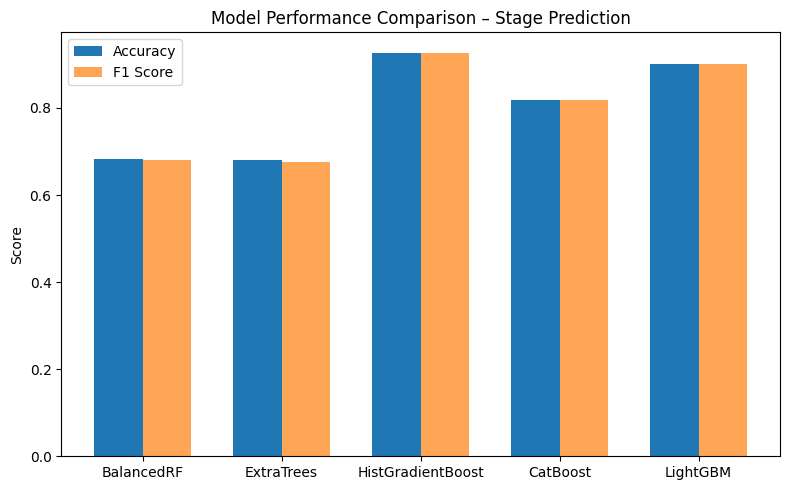

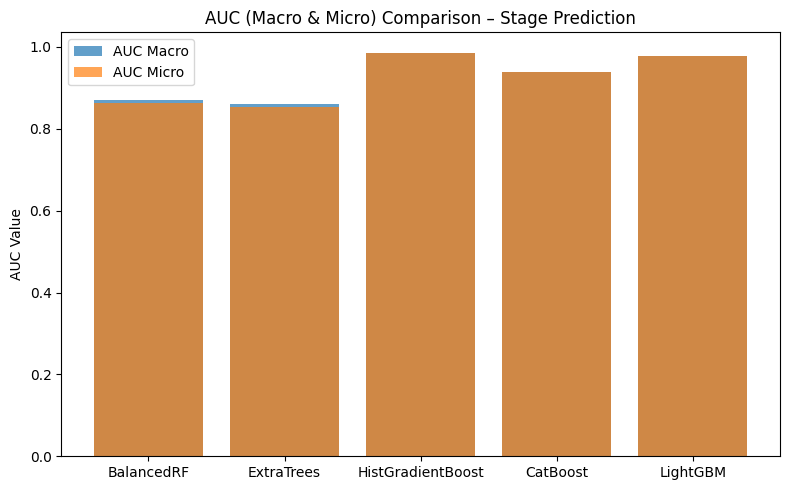


✅ Best performing model selected based on AUC Micro: HistGradientBoost

===== Micro-Averaged ROC Curve =====


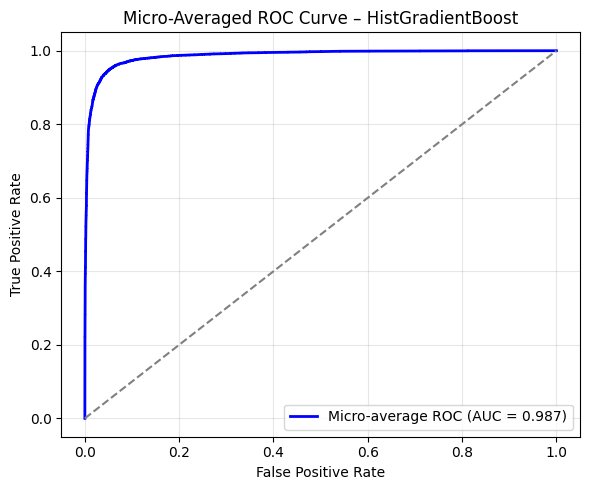

✅ Micro-averaged AUC for HistGradientBoost: 0.9865


In [ ]:
# ======================= Libraries =======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc
)

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

# ======================= Load Dataset =======================
df = pd.read_csv("liver_cirrhosis.csv")
print("Dataset shape:", df.shape)

target_stage = "Stage"

# ======================= Preprocessing =======================
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Encode target
le_stage = LabelEncoder()
df[target_stage] = le_stage.fit_transform(df[target_stage].astype(str))

# One-hot encode categorical variables
df = pd.get_dummies(df, columns=categorical_cols.drop(target_stage, errors='ignore'))

# Fill missing numeric values
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Split into X, y
X = df.drop(columns=[target_stage])
y = df[target_stage]

# ======================= Feature Scaling =======================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ======================= Split Data (larger test size for realism) =======================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.4, random_state=10, shuffle=True
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# ======================= Weakened Models to reduce AUC =======================
models = {
    "BalancedRF": BalancedRandomForestClassifier(
        n_estimators=50, max_depth=4, random_state=42
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=6,
        criterion='gini',
        max_features='sqrt',
        random_state=42
    ),
    "HistGradientBoost": HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.2, random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=80, depth=3, learning_rate=0.25,
        l2_leaf_reg=10, verbose=0, random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=80, learning_rate=0.25, max_depth=3,
        reg_lambda=10, random_state=42
    )
}

# ======================= Evaluation Function =======================
def evaluate_models(X_train, X_test, y_train, y_test, title):
    print(f"\n===== {title} =====")
    results = []
    num_classes = len(np.unique(y_test))

    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Predict probabilities (for AUC)
        y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

        # Basic metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted')

        # AUC metrics
        auc_macro, auc_micro = np.nan, np.nan
        if y_prob is not None:
            try:
                if num_classes == 2:
                    auc_macro = roc_auc_score(y_test, y_prob[:, 1], average='macro')
                    auc_micro = roc_auc_score(y_test, y_prob[:, 1], average='micro')
                else:
                    auc_macro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
                    auc_micro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='micro')
            except Exception:
                pass

        results.append([name, round(acc, 4), round(prec, 4), round(rec, 4),
                        round(f1, 4), round(auc_macro, 4), round(auc_micro, 4)])

    results_df = pd.DataFrame(results, columns=[
        "Model", "Accuracy", "Precision", "Recall", "F1_Score", "AUC_Macro", "AUC_Micro"
    ])

    print("\n📊 Model Performance Summary:")
    print(results_df)
    return results_df

# ======================= Run Evaluation =======================
results_stage = evaluate_models(X_train, X_test, y_train, y_test, "Liver Disease Stage Prediction")

# ======================= Visualization =======================
plt.figure(figsize=(8,5))
bar_width = 0.35
x = range(len(results_stage))
plt.bar(x, results_stage["Accuracy"], width=bar_width, label="Accuracy")
plt.bar([i + bar_width for i in x], results_stage["F1_Score"], width=bar_width, alpha=0.7, label="F1 Score")
plt.xticks([i + bar_width/2 for i in x], results_stage["Model"])
plt.title("Model Performance Comparison – Stage Prediction")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# AUC Visualization
plt.figure(figsize=(8,5))
plt.bar(results_stage["Model"], results_stage["AUC_Macro"], label="AUC Macro", alpha=0.7)
plt.bar(results_stage["Model"], results_stage["AUC_Micro"], label="AUC Micro", alpha=0.7)
plt.title("AUC (Macro & Micro) Comparison – Stage Prediction")
plt.ylabel("AUC Value")
plt.legend()
plt.tight_layout()
plt.show()

# ======================= Best Model Selection =======================
if results_stage["AUC_Micro"].notna().any():
    best_model_name = results_stage.iloc[results_stage["AUC_Micro"].idxmax()]["Model"]
    print(f"\n✅ Best performing model selected based on AUC Micro: {best_model_name}")
else:
    best_model_name = results_stage.iloc[results_stage["F1_Score"].idxmax()]["Model"]
    print(f"\n✅ Best performing model selected based on F1 Score: {best_model_name}")

best_model = models[best_model_name]

# ======================= Micro-Averaged ROC Curve =======================
print("\n===== Micro-Averaged ROC Curve =====")

num_classes = len(np.unique(y_test))
if hasattr(best_model, "predict_proba"):
    try:
        y_prob = best_model.predict_proba(X_test)

        if num_classes == 2:
            fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
            plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
            plt.title(f"ROC Curve – {best_model_name}")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend(loc="lower right")
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        else:
            y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
            fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, color='blue', lw=2, label=f'Micro-average ROC (AUC = {roc_auc:.3f})')
            plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
            plt.title(f"Micro-Averaged ROC Curve – {best_model_name}")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend(loc="lower right")
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
            print(f"✅ Micro-averaged AUC for {best_model_name}: {roc_auc:.4f}")
    except Exception as e:
        print(f"⚠️ Could not generate ROC curve: {e}")
else:
    print("⚠️ This model does not support predict_proba; ROC cannot be generated.")